In [2]:
import pandas as pd

dtypes = {
    "AIRLINE": "category", "AIRLINE_DOT": "category", "AIRLINE_CODE": "category",
    "DOT_CODE": "int32", "FL_NUMBER": "int32",
    "ORIGIN": "category", "ORIGIN_CITY": "category",
    "DEST": "category", "DEST_CITY": "category",
    "CRS_DEP_TIME": "int16", "CRS_ARR_TIME": "int16",
}
df = pd.read_csv(
    "../data/raw/flights_sample_3m.csv",
    dtype=dtypes,
    parse_dates=["FL_DATE"],
)
print(df.shape)
print(df["FL_DATE"].min(), "→", df["FL_DATE"].max())

(3000000, 32)
2019-01-01 00:00:00 → 2023-08-31 00:00:00


In [3]:
df["delayed"] = (df["ARR_DELAY"] > 15).astype("float")  # float so NaNs (cancelled) stay NaN
by_year = df.groupby(df["FL_DATE"].dt.year)["delayed"].agg(["mean", "count"])
print(by_year)

             mean   count
FL_DATE                  
2019     0.180183  757673
2020     0.088061  479350
2021     0.162748  611633
2022     0.197309  687860
2023     0.218549  463484


In [4]:
by_month = (
    df.groupby([df["FL_DATE"].dt.year.rename("year"),
                df["FL_DATE"].dt.month.rename("month")])["delayed"]
      .mean().unstack()
)
by_month.round(3)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2019,0.173,0.219,0.161,0.171,0.190,0.234,0.198,0.195,0.131,0.158,0.137,0.195
2020,0.130,0.143,0.079,0.027,0.043,0.060,0.081,0.074,0.059,0.079,0.071,0.112
2021,0.093,0.132,0.096,0.102,0.127,0.227,0.238,0.214,0.132,0.171,0.142,0.206
2022,0.174,0.181,0.205,0.213,0.198,0.228,0.223,0.209,0.155,0.150,0.181,0.245
2023,0.209,0.176,0.231,0.218,0.173,0.254,0.273,0.207,NaN,NaN,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False).round(3)

CANCELLATION_CODE          0.974
DELAY_DUE_SECURITY         0.822
DELAY_DUE_LATE_AIRCRAFT    0.822
DELAY_DUE_WEATHER          0.822
DELAY_DUE_CARRIER          0.822
DELAY_DUE_NAS              0.822
AIR_TIME                   0.029
ARR_DELAY                  0.029
ELAPSED_TIME               0.029
WHEELS_ON                  0.027
TAXI_IN                    0.027
ARR_TIME                   0.027
WHEELS_OFF                 0.026
TAXI_OUT                   0.026
DEP_DELAY                  0.026
DEP_TIME                   0.026
CRS_ELAPSED_TIME           0.000
FL_DATE                    0.000
DEST_CITY                  0.000
CRS_DEP_TIME               0.000
DOT_CODE                   0.000
FL_NUMBER                  0.000
ORIGIN                     0.000
ORIGIN_CITY                0.000
DEST                       0.000
AIRLINE_DOT                0.000
AIRLINE                    0.000
AIRLINE_CODE               0.000
CRS_ARR_TIME               0.000
DIVERTED                   0.000
CANCELLED 

In [6]:
print("cancelled flights:", int(df["CANCELLED"].sum()))
print("rows with null ARR_DELAY:", int(df["ARR_DELAY"].isna().sum()))
print("null ARR_DELAY that are cancelled:",
      int(df.loc[df["ARR_DELAY"].isna(), "CANCELLED"].sum()))

cancelled flights: 79140
rows with null ARR_DELAY: 86198
null ARR_DELAY that are cancelled: 79140


In [7]:
df[["AIRLINE", "ORIGIN", "DEST", "CANCELLATION_CODE"]].nunique()

AIRLINE               18
ORIGIN               380
DEST                 380
CANCELLATION_CODE      4
dtype: int64

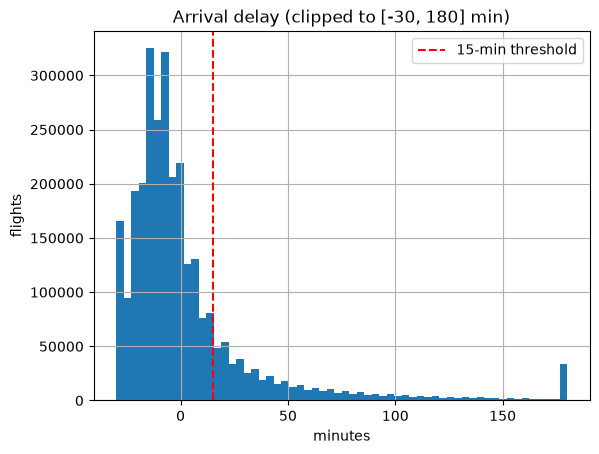

In [8]:
import matplotlib.pyplot as plt

ax = df["ARR_DELAY"].clip(-30, 180).hist(bins=60)
ax.set_title("Arrival delay (clipped to [-30, 180] min)")
ax.set_xlabel("minutes"); ax.set_ylabel("flights")
plt.axvline(15, color="red", linestyle="--", label="15-min threshold")
plt.legend(); plt.show()

In [9]:
print("exact duplicate rows:", int(df.duplicated().sum()))

exact duplicate rows: 0


In [10]:
print(df["CRS_DEP_TIME"].describe())
print("values >= 2400:", int((df["CRS_DEP_TIME"] >= 2400).sum()))
print("sample:", sorted(df["CRS_DEP_TIME"].unique())[:5],
      "...", sorted(df["CRS_DEP_TIME"].unique())[-5:])

count    3.000000e+06
mean     1.327062e+03
std      4.858789e+02
min      1.000000e+00
25%      9.150000e+02
50%      1.320000e+03
75%      1.730000e+03
max      2.359000e+03
Name: CRS_DEP_TIME, dtype: float64
values >= 2400: 0
sample: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5)] ... [np.int16(2355), np.int16(2356), np.int16(2357), np.int16(2358), np.int16(2359)]
